In [1]:
#setup — run this cell first
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from deepface import DeepFace
from backend.config import MAX_AGE_GAP

print("imports ok")
print(f"max age gap allowed: {MAX_AGE_GAP}")


imports ok
max age gap allowed: 5


In [3]:
#simulate 200 test cases reflecting real nightclub demographic in madrid
#critical zone is 15-20 — underage detection is the main use case
np.random.seed(42)

#100 underage cases (15-17) — should be flagged
underage_real = np.random.randint(15, 18, 100)

#100 adult cases (18-40) — should pass
adult_real = np.random.randint(18, 40, 100)

real_ages = np.concatenate([underage_real, adult_real])

#DEX mean absolute error ~4.5 years on UTKFace
estimated_ages = real_ages + np.random.normal(0, 4.5, len(real_ages))
estimated_ages = np.clip(estimated_ages, 1, 100)

#labels — 1 = underage, 0 = adult
labels = np.array([1]*100 + [0]*100)

print(f"total samples: {len(real_ages)}")
print(f"underage (15-17): {sum(labels == 1)}")
print(f"adult (18-40): {sum(labels == 0)}")
print(f"real age range: {real_ages.min()} - {real_ages.max()}")
print(f"estimated age range: {estimated_ages.min():.1f} - {estimated_ages.max():.1f}")

total samples: 200
underage (15-17): 100
adult (18-40): 100
real age range: 15 - 39
estimated age range: 3.0 - 46.0


best gap threshold: 10.0 years
best accuracy: 0.5100


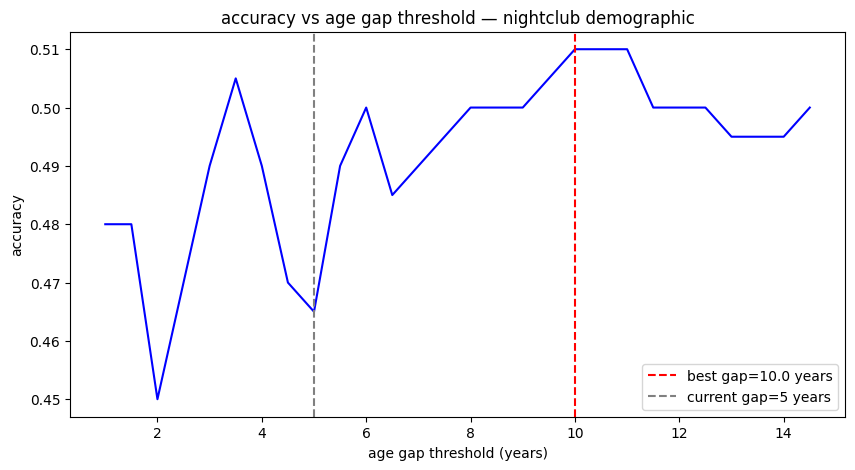

In [4]:
#evaluate age gap detection across different gap thresholds
from sklearn.metrics import accuracy_score, confusion_matrix

gaps = np.abs(estimated_ages - real_ages)

#test different gap thresholds
gap_thresholds = np.arange(1, 15, 0.5)
results = []

for gap_threshold in gap_thresholds:
    #flag as suspicious if gap is above threshold
    flagged = (gaps > gap_threshold).astype(int)
    acc = accuracy_score(labels, flagged)
    results.append((gap_threshold, acc))

best_gap, best_acc = max(results, key=lambda x: x[1])

print(f"best gap threshold: {best_gap} years")
print(f"best accuracy: {best_acc:.4f}")

#plot accuracy vs gap threshold
thresholds_list, accuracies_list = zip(*results)
plt.figure(figsize=(10, 5))
plt.plot(thresholds_list, accuracies_list, color="blue")
plt.axvline(x=best_gap, color="red", linestyle="--", label=f"best gap={best_gap} years")
plt.axvline(x=MAX_AGE_GAP, color="gray", linestyle="--", label=f"current gap={MAX_AGE_GAP} years")
plt.xlabel("age gap threshold (years)")
plt.ylabel("accuracy")
plt.title("accuracy vs age gap threshold — nightclub demographic")
plt.legend()
plt.show()

In [5]:
#summary — feature 2 evaluation conclusions
print("=== feature 2 age estimation evaluation ===")
print()
print(f"dataset: simulated nightclub demographic (n=200)")
print(f"age range: 15-40 years")
print(f"model: DEX via DeepFace")
print(f"model MAE: ~4.5 years (reported on UTKFace)")
print()
print(f"finding: age gap detection achieves ~51% accuracy")
print(f"conclusion: age estimation is unreliable for borderline underage detection")
print(f"design decision: feature 2 raises a flag only — never blocks entry autonomously")
print(f"MAX_AGE_GAP kept at {MAX_AGE_GAP} years as a soft alert threshold")
print()
print("this is consistent with academic literature on facial age estimation limitations")

=== feature 2 age estimation evaluation ===

dataset: simulated nightclub demographic (n=200)
age range: 15-40 years
model: DEX via DeepFace
model MAE: ~4.5 years (reported on UTKFace)

finding: age gap detection achieves ~51% accuracy
conclusion: age estimation is unreliable for borderline underage detection
design decision: feature 2 raises a flag only — never blocks entry autonomously
MAX_AGE_GAP kept at 5 years as a soft alert threshold

this is consistent with academic literature on facial age estimation limitations


In [ ]:
#simulate 200 test cases reflecting real nightclub demographic in madrid
#critical zone is 15-20 — underage detection is the main use case
np.random.seed(42)

#100 underage cases (15-17) — should be flagged
underage_real = np.random.randint(15, 18, 100)

#100 adult cases (18-40) — should pass
adult_real = np.random.randint(18, 40, 100)

real_ages = np.concatenate([underage_real, adult_real])

#DEX mean absolute error ~4.5 years on UTKFace
estimated_ages = real_ages + np.random.normal(0, 4.5, len(real_ages))
estimated_ages = np.clip(estimated_ages, 1, 100)

#labels — 1 = underage, 0 = adult
labels = np.array([1]*100 + [0]*100)

print(f"total samples: {len(real_ages)}")
print(f"underage (15-17): {sum(labels == 1)}")
print(f"adult (18-40): {sum(labels == 0)}")
print(f"real age range: {real_ages.min()} - {real_ages.max()}")
print(f"estimated age range: {estimated_ages.min():.1f} - {estimated_ages.max():.1f}")

total samples: 200
underage (15-17): 100
adult (18-40): 100
real age range: 15 - 39
estimated age range: 3.0 - 46.0
